In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import fft, signal, stats
from tqdm.notebook import tqdm
from tpot import TPOTClassifier

In [4]:
healthy_data = pd.read_csv("healthy_data.csv", usecols=['H1_AN3', 'H1_AN4', 'H1_AN5', 'H1_AN6', 'H1_AN7', 'H1_AN8', 'H1_AN9',
       'H1_AN10'])
damaged_data = pd.read_csv("damaged_data.csv", usecols=['D1_AN3', 'D1_AN4', 'D1_AN5', 'D1_AN6', 'D1_AN7', 'D1_AN8', 'D1_AN9',
       'D1_AN10'])

In [5]:
healthy_data.columns = healthy_data.columns.str.replace('H', 'S')
damaged_data.columns = damaged_data.columns.str.replace('D', 'S')

In [6]:
common_cols = healthy_data.columns.intersection(damaged_data.columns)
new_healthy_data = healthy_data[common_cols]
new_damage_data = damaged_data[common_cols]

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
healthy_data_scaled = scaler.fit_transform(new_healthy_data)
damaged_data_scaled = scaler.fit_transform(new_damage_data)

In [8]:
healthy_data_scaled = pd.DataFrame(healthy_data_scaled, columns=common_cols)
damaged_data_scaled = pd.DataFrame(damaged_data_scaled, columns=common_cols)
healthy_data_scaled['State'] = 1
damaged_data_scaled['State'] = 0

In [9]:
damaged_data_scaled.head()

,S1_AN3,S1_AN4,S1_AN5,S1_AN6,S1_AN7,S1_AN8,S1_AN9,S1_AN10,State
0,0.895728,-0.803695,-0.591388,0.614164,0.710708,-0.703050,2.922758,-0.699389,0
1,0.554000,-0.893921,-0.601161,-0.200874,-0.132659,-0.740684,1.918620,-1.762388,0
2,0.281159,-0.977420,-0.332221,-1.006774,-0.055339,-0.600491,0.682754,-2.317633,0
3,0.262082,-1.184668,0.145119,-0.477495,0.225374,-0.688108,-0.468001,-2.007984,0
4,0.596071,-1.245294,0.287394,0.211928,0.078648,-1.190833,-1.278761,-1.355123,0


In [10]:
healthy_data_scaled.head()

,S1_AN3,S1_AN4,S1_AN5,S1_AN6,S1_AN7,S1_AN8,S1_AN9,S1_AN10,State
0,-0.723576,0.392498,-1.297769,-0.614003,1.667086,-0.625596,-0.899137,-0.257976,1
1,-1.234167,0.511543,-1.660811,-0.459000,1.490400,-0.670187,-1.098397,0.074411,1
2,-1.869075,-0.116025,-1.866484,1.075076,-0.285620,-0.303620,-1.273740,0.215844,1
3,-2.372654,0.160905,-1.729564,0.850225,-0.163598,-0.434786,-1.421717,-0.011301,1
4,-2.352900,0.805045,-1.347538,0.365857,-0.514413,-0.533591,-1.519198,0.029443,1


In [11]:
dfGbxData = pd.concat([healthy_data_scaled, damaged_data_scaled]).reset_index()
dfGbxData = dfGbxData.sample(frac=1, random_state=42).reset_index(drop=True)
dfGbxData.head()

,index,S1_AN3,S1_AN4,S1_AN5,S1_AN6,S1_AN7,S1_AN8,S1_AN9,S1_AN10,State
0,2143565,1.420337,1.881011,-0.654054,0.607794,-2.277450,-0.089638,-1.465412,0.059851,0
1,2047403,0.554301,-0.245624,0.692329,-0.980663,-0.113706,-0.200461,-1.223790,1.581912,1
2,1069280,1.928160,0.165260,0.362086,0.801961,0.951499,1.317670,-0.041674,0.154458,0
3,221000,0.904828,-0.466777,0.142159,-1.509096,1.150754,-0.970794,-0.500436,0.623257,1
4,740116,0.367642,2.494176,-0.394378,-0.191852,-0.963240,0.931387,-0.263939,-0.782581,1


In [12]:
features = dfGbxData.columns[1:-1]

In [13]:
sensor_readings = dfGbxData.melt(
    id_vars=['State'],
    value_vars=features,
    var_name='sensor',
    value_name='reading'
)

In [14]:
sensor_readings.head()

,State,sensor,reading
0,0,S1_AN3,1.420337
1,1,S1_AN3,0.554301
2,0,S1_AN3,1.928160
3,1,S1_AN3,0.904828
4,1,S1_AN3,0.367642


In [15]:
sensor_readings.describe()

,State,reading
count,38400000.0,3.840000e+07
mean,0.5,8.147557e-18
std,0.5,1.000000e+00
min,0.0,-6.913239e+00
25%,0.0,-6.807854e-01
50%,0.5,-2.310133e-03
75%,1.0,6.786963e-01
max,1.0,5.949229e+00


In [16]:
def rdg(df, State=None, sensor=None):
    df_st = df[df.State==State] if State is not None else df
    df_se = df_st[df_st.sensor==sensor] if sensor is not None else df_st
    return df_se

In [17]:
sensor_data = rdg(sensor_readings, 1, 'S1_AN3').reading.values

1200001 total number of frequency points


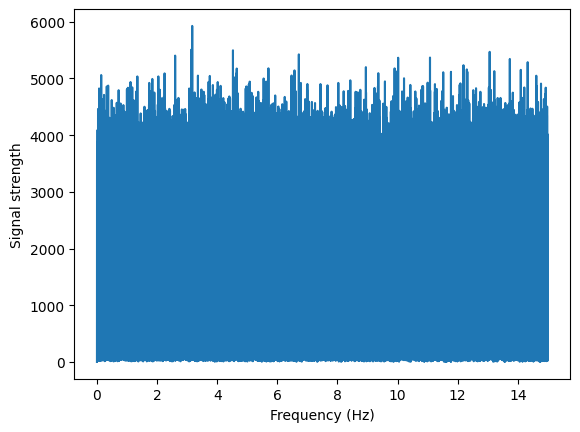

In [18]:
y = np.abs(fft.rfft(sensor_data))
x = fft.rfftfreq(sensor_data.shape[0], 1/30)  # 30Hz data rate
print(f"{y.shape[0]} total number of frequency points")

plt.plot(x, y)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Signal strength')
plt.show()

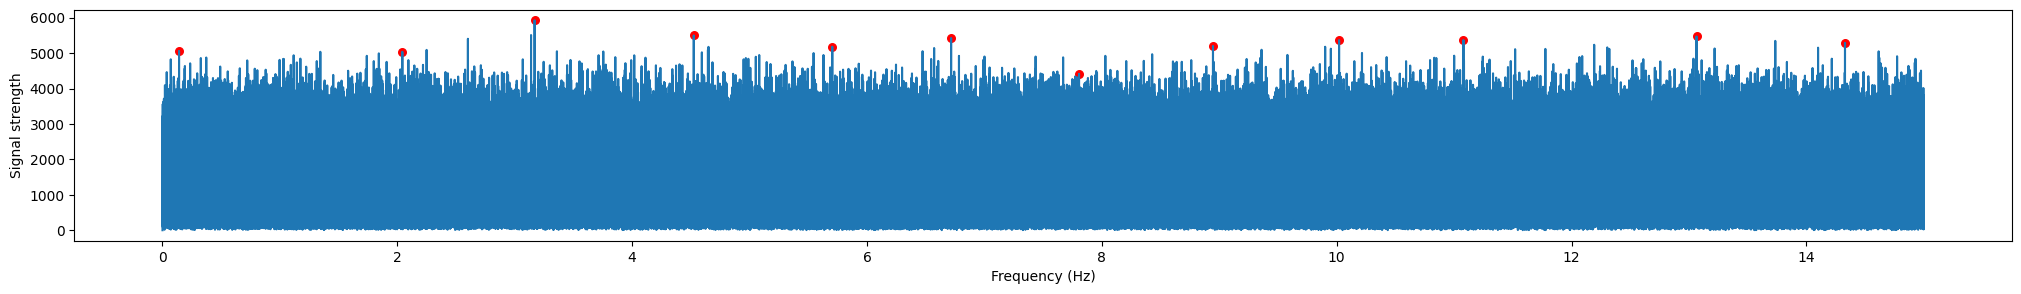

In [19]:
y = np.abs(fft.rfft(sensor_data))
x = fft.rfftfreq(sensor_data.shape[0], 1/30)  # 30Hz data rate

fig, ax = plt.subplots(figsize=(25,3))
ax.plot(x, y)

# find peaks that are
#   at least 1Hz apart (number of frequency points / max frequency)
x_peak_spacing = y.shape[0] / x.max()
#   rising above surrounding values by the 99th percentile of the values
x_peak_prominence = np.quantile(y,0.99)

peaks, _ = signal.find_peaks(y, distance=x_peak_spacing, prominence=x_peak_prominence)

for peak in peaks:
    ax.scatter(x=x[peak], y=y[peak], c='r', marker='o', s=30)

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Signal strength')
plt.show()

In [20]:
[x[peak] for peak in peaks]

[np.float64(0.1411625),
 np.float64(2.042625),
 np.float64(3.16915),
 np.float64(4.5246625),
 np.float64(5.704162500000001),
 np.float64(6.7161625),
 np.float64(7.805537500000001),
 np.float64(8.946362500000001),
 np.float64(10.0201375),
 np.float64(11.079325),
 np.float64(13.0641625),
 np.float64(14.3286625)]

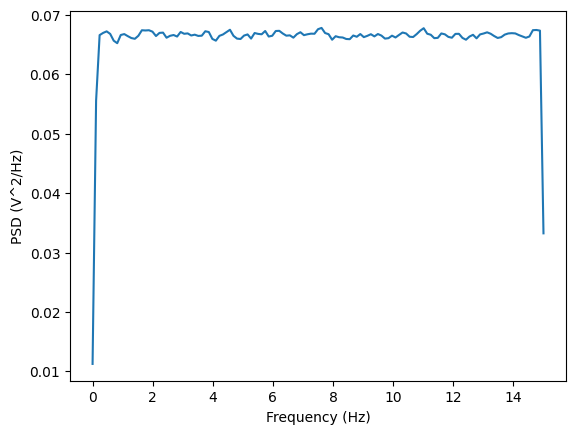

In [21]:
x, y = signal.welch(sensor_data, fs=30) # 30Hz data rate
plt.plot(x, y)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (V^2/Hz)')
plt.show()

  0%|          | 0/40 [00:00<?, ?it/s]

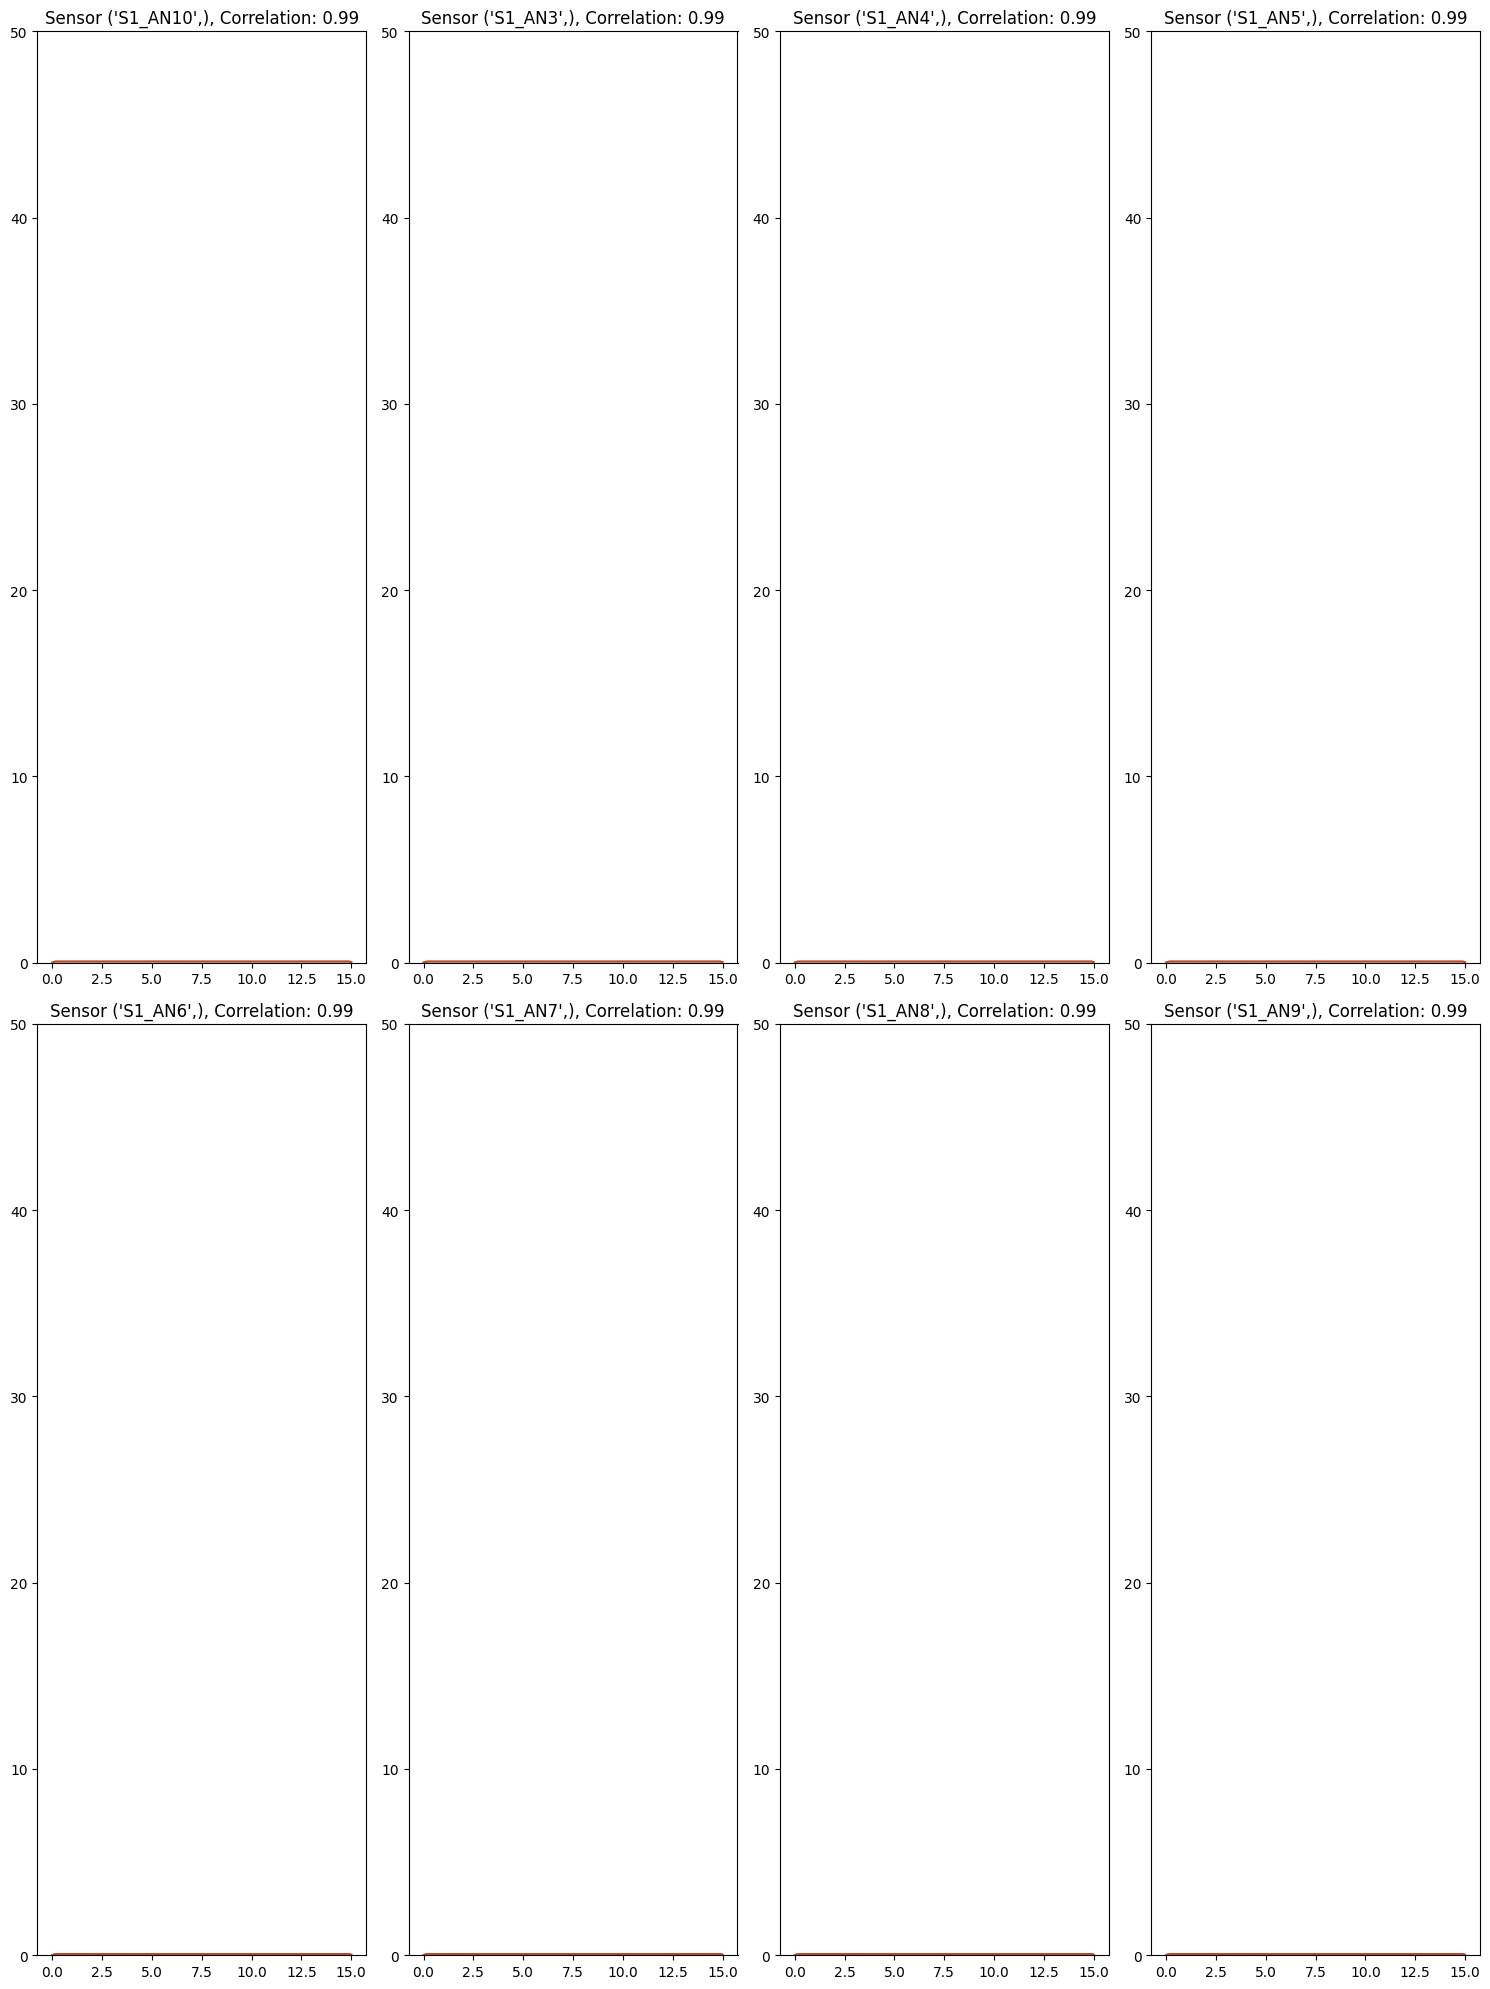

In [22]:
fig, ax = plt.subplots(ncols=4, nrows=2, figsize=(15,20))
for ((sensor), dfg), axi in tqdm(zip(sensor_readings.groupby(['sensor']), ax.ravel()), total=40):
    healthy_raw = dfg[dfg.State==1].reading.values
    damaged_raw = dfg[dfg.State==0].reading.values
    
    fh, Ph = signal.welch(healthy_raw, fs=30)
    fb, Pb = signal.welch(damaged_raw, fs=30)

    axi.plot(fh, Ph, c='g', alpha=0.6)
    axi.plot(fb, Pb, c='r', alpha=0.6)
    axi.set_ylim(0,50)
    axi.set_title(f'Sensor {sensor}, Correlation: {np.corrcoef(Ph, Pb)[0,1]:0.2}')
plt.tight_layout()
plt.show()

In [58]:
data = []
labels = []
for (state,sensor),g in sensor_readings.groupby(['State','sensor']):
    vals = g.reading.values
    splits = np.split(vals, range(1000,vals.shape[0],1000))
    for s in splits[:-1]:  # except the last one
        data.append({
            'SAN3': int(sensor=='AN3'),
            'SAN4': int(sensor=='AN4'),
            'SAN5': int(sensor=='AN5'),
            'SAN6': int(sensor=='AN6'),
            'SAN7': int(sensor=='AN7'),
            'SAN8': int(sensor=='AN8'),
            'SAN9': int(sensor=='AN9'),
            'SAN10': int(sensor=='AN10'),
            'mean': np.mean(s),
            'std': np.std(s),
            'kurt': stats.kurtosis(s),
            'skew': stats.skew(s),
            'moment': stats.moment(s),
        })
        labels.append(int(state==0))  # positive label indicates fault

df_data = pd.DataFrame(data)
data = df_data.values
labels = np.array(labels)
(data.shape, labels.shape)

((38384, 13), (38384,))

In [59]:
(data.shape, labels.shape)

((38384, 13), (38384,))

In [24]:
df_data.head()

,SAN3,SAN4,SAN5,SAN6,SAN7,SAN8,SAN9,SAN10,mean,std,kurt,skew,moment
0,0,0,0,0,0,0,0,0,0.018676,0.995447,0.001406,-0.163318,0.0
1,0,0,0,0,0,0,0,0,0.069280,0.977841,-0.058102,-0.046291,0.0
2,0,0,0,0,0,0,0,0,-0.017689,0.999326,-0.158268,0.075582,0.0
3,0,0,0,0,0,0,0,0,-0.025099,0.990371,-0.141455,0.017012,0.0
4,0,0,0,0,0,0,0,0,-0.018135,1.006867,-0.113000,-0.003390,0.0


In [25]:
df_data.describe()

,SAN3,SAN4,SAN5,SAN6,SAN7,SAN8,SAN9,SAN10,mean,std,kurt,skew,moment
count,38384.0,38384.0,38384.0,38384.0,38384.0,38384.0,38384.0,38384.0,38384.000000,38384.000000,38384.000000,38384.000000,38384.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000001,0.999253,-0.061474,0.013614,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.031626,0.022146,0.204778,0.093530,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.131838,0.912130,-0.628569,-0.341955,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.021330,0.984116,-0.206880,-0.050366,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.000244,0.999203,-0.078552,0.012624,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.021370,1.014040,0.061801,0.076013,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.142462,1.115802,1.507113,0.469887,0.0


In [26]:
print(f'Total samples: {len(labels)}')
print(f'Fault class: {np.sum(labels)} ({np.sum(labels)/len(labels):0.1%})')

Total samples: 38384
Fault class: 19192 (50.0%)


In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    data, labels,
    train_size=0.8,
    random_state=42,
    stratify=labels
)
print(f'Training data: {X_train.shape}')
print(f'Test data: {X_test.shape}')

Training data: (30707, 13)
Test data: (7677, 13)


Supervised Learning

In [28]:
tpot_fd = TPOTClassifier(generations=5, random_state=42, max_time_mins=2)
tpot_fd.fit(X_train, y_train)
print(f'Best accuracy score: {tpot_fd.score(X_test, y_test):0.3%}')

Version 0.12.2 of tpot is outdated. Version 1.1.0 was released Thursday July 03, 2025.


Best accuracy score: 61.092%


In [29]:
pd.Series([
    model.split('(')[0]
    for model
    in tpot_fd.evaluated_individuals_.keys()
]).value_counts()

ExtraTreesClassifier          6
MLPClassifier                 3
GaussianNB                    2
SGDClassifier                 2
XGBClassifier                 2
BernoulliNB                   2
RandomForestClassifier        1
KNeighborsClassifier          1
MultinomialNB                 1
DecisionTreeClassifier        1
GradientBoostingClassifier    1
Name: count, dtype: int64

Random Forest and Ada Boost

In [49]:
# initialize the adaBoost classifier with a base estimator
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import AdaBoostClassifier
baseEstimator = RandomForestClassifier(n_estimators=100, random_state=42)
adaboost_model = AdaBoostClassifier(estimator=baseEstimator,n_estimators=50,learning_rate=1.0,random_state=42)

# Train
adaboost_model.fit(X_train, y_train)

# Predict
y_pred = adaboost_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:\n", report)

c:\users\anand.khare\documents\learnings\venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy: 0.5792627328383483
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.57      0.57      3839
           1       0.58      0.59      0.58      3838

    accuracy                           0.58      7677
   macro avg       0.58      0.58      0.58      7677
weighted avg       0.58      0.58      0.58      7677



In [63]:
from scipy.stats import f_oneway
feature_cols = ['mean', 'std', 'kurt', 'skew']
features_with_no_dependancy = []
df_stats = df_data[['mean', 'std', 'kurt', 'skew']]
df_stats['State'] = labels
df_stats.head()

C:\Users\anand.khare\AppData\Local\Temp\ipykernel_18440\3025589756.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_stats['State'] = labels


,mean,std,kurt,skew,State
0,0.018676,0.995447,0.001406,-0.163318,1
1,0.069280,0.977841,-0.058102,-0.046291,1
2,-0.017689,0.999326,-0.158268,0.075582,1
3,-0.025099,0.990371,-0.141455,0.017012,1
4,-0.018135,1.006867,-0.113000,-0.003390,1


In [64]:
for i in range(0, len(feature_cols)):
    # Group the numerical variable by target class
    groups = [group[feature_cols[i]].values for State, group in df_stats.groupby('State')]
    
    # Run ANOVA
    f_stat, p_value = f_oneway(*groups)  
    
    
    # Visualize
    #sns.boxplot(x='State', y='S1_Speed', data=dfGbxData)
    #plt.title('Speed vs State correlation')
    #plt.show()
    
    if p_value < 0.05:
        print("Significant dependency between " + feature_cols[i] + " and State.")
    else:
        print("No significant dependency between " + feature_cols[i] + " and State.")
        features_with_no_dependancy.append(feature_cols[i])
    print(f"F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_value:.4f}")


No significant dependency between mean and State.
F-statistic: 0.0001
p-value: 0.9920
No significant dependency between std and State.
F-statistic: 0.0140
p-value: 0.9059
Significant dependency between kurt and State.
F-statistic: 457.6112
p-value: 0.0000
Significant dependency between skew and State.
F-statistic: 475.4972
p-value: 0.0000


In [65]:
xModel = df_stats.drop(columns=['mean', 'std', 'State'], axis=1, errors='ignore')
yModel = df_stats['State']
print(xModel.shape)
print(yModel.shape)

(38384, 2)
(38384,)


In [66]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    xModel, yModel,
    train_size=0.8,
    random_state=42,
    stratify=yModel
)

In [67]:
# Standarise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# initialize the adaBoost classifier with a base estimator
baseEstimator = RandomForestClassifier(n_estimators=100, random_state=42)
adaboost_model = AdaBoostClassifier(estimator=baseEstimator,n_estimators=50,learning_rate=1.0,random_state=42)

# Train
adaboost_model.fit(X_train_scaled, y_train)

# Predict
y_pred = adaboost_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:\n", report)


c:\users\anand.khare\documents\learnings\venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy: 0.5595935912465807
Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.54      0.55      3839
           1       0.56      0.57      0.57      3838

    accuracy                           0.56      7677
   macro avg       0.56      0.56      0.56      7677
weighted avg       0.56      0.56      0.56      7677



In [68]:
from tpot import TPOTClassifier
tpot_td = TPOTClassifier(generations=5, random_state=42, max_time_mins=2)
tpot_td.fit(X_train, y_train)
print(f'Best accuracy score: {tpot_td.score(X_test, y_test):0.3%}')

Version 0.12.2 of tpot is outdated. Version 1.1.0 was released Thursday July 03, 2025.


Best accuracy score: 60.323%


In [69]:
pd.Series([
    model.split('(')[0]
    for model
    in tpot_td.evaluated_individuals_.keys()
]).value_counts()

XGBClassifier                 5
BernoulliNB                   2
RandomForestClassifier        2
KNeighborsClassifier          2
ExtraTreesClassifier          2
GradientBoostingClassifier    2
GaussianNB                    1
MLPClassifier                 1
SGDClassifier                 1
Name: count, dtype: int64